# EDDA Dementia Prediction - XGBoost

Working through the simulated dataset to replicate the EDDA approach in a new health system.
Following the general structure from Cohen et al. 2025 but adapting to this dataset.

Steps: data cleaning → Table 1 → train/test split → XGBoost → evaluation

## 1. Load & Explore Data

In [4]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = r'C:\Users\honol\Documents\Hwang_lab_interview\simulated_edda.xlsx'

df = pd.read_excel(DATA_PATH, sheet_name=1)
print(df.shape)
df.head()

(100000, 26)


,patient_id,visit_id,age,sex,race_ethnicity,insurance_status,n_geri_any,n_prior_hosps_24mo,n_prior_ed_visits_24mo,n_prior_ed_visits_6mo,...,outptmeds_AUTONOMICDRUGS,outptmeds_PSYCHOTHERAPEUTICDRUGS,labcont_LEUKOCYTES UA,n_dementia_drugs_24mo_multiple,rx_donepezil,rx_dementia_yn,proc_otherproc_ed,proc_headct_ed,previousdispo_na,dementia_outcome
0,PT036420,PT036420-V01,58.5,Male,Hispanic or Latino,Other,3.0,0.0,NaN,0.0,...,0,0.0,0.0,1.0,0.0,1.0,NaN,0.0,Admit,0
1,PT016914,PT016914-V02,62.9,Female,White Non-Hispanic,Medicare,2.0,1.0,2.0,NaN,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Discharge,0
2,PT025876,PT025876-V01,67.8,Female,White Non-Hispanic,Medicare,NaN,5.0,5.0,2.0,...,0,0.0,0.0,0.0,NaN,NaN,0.0,NaN,Observation,0
3,PT037066,PT037066-V03,83.9,Female,Black or African American,Medicaid,2.0,2.0,5.0,4.0,...,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,Admit,1
4,PT001420,PT001420-V01,77.2,Female,Hispanic or Latino,Medicare,4.0,3.0,2.0,2.0,...,0,0.0,NaN,1.0,0.0,1.0,NaN,0.0,LWBS before Triage,0


In [5]:
# check columns and outcome balance
print(df.columns.tolist())
print()
print(df['dementia_outcome'].value_counts())
print(f"prevalence: {df['dementia_outcome'].mean()*100:.1f}%")

['patient_id', 'visit_id', 'age', 'sex', 'race_ethnicity', 'insurance_status', 'n_geri_any', 'n_prior_hosps_24mo', 'n_prior_ed_visits_24mo', 'n_prior_ed_visits_6mo', 'labcont_MPV_min', 'elixhauser_score', 'hxdx_parkinsons', 'hxdx_ecodesfall', 'hxdx_comabrndmg', 'hxdx_schizophreniaandotherpsychoticdisorde', 'outptmeds_AUTONOMICDRUGS', 'outptmeds_PSYCHOTHERAPEUTICDRUGS', 'labcont_LEUKOCYTES UA', 'n_dementia_drugs_24mo_multiple', 'rx_donepezil', 'rx_dementia_yn', 'proc_otherproc_ed', 'proc_headct_ed', 'previousdispo_na', 'dementia_outcome']

dementia_outcome
0    78359
1    21641
Name: count, dtype: int64
prevalence: 21.6%


In [6]:
# see what's missing
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({'n': missing, 'pct': missing_pct})[missing > 0]

,n,pct
labcont_LEUKOCYTES UA,29960,30.0
labcont_MPV_min,24929,24.9
proc_otherproc_ed,20026,20.0
proc_headct_ed,19958,20.0
outptmeds_AUTONOMICDRUGS,15046,15.0
outptmeds_PSYCHOTHERAPEUTICDRUGS,15022,15.0
elixhauser_score,14960,15.0
hxdx_schizophreniaandotherpsychoticdisorde,12006,12.0
n_prior_ed_visits_24mo,12002,12.0
n_prior_ed_visits_6mo,11963,12.0


## 2. Data Cleaning

A few issues I found:
- `age` came in as object dtype (has some non-numeric entries)
- `outptmeds_AUTONOMICDRUGS` has mixed Yes/No strings alongside 0/1 numeric
- sex/race/insurance have inconsistent capitalization
- lab features have up to ~30% missingness -- will handle in the pipeline

In [7]:
# age was object, convert to numeric (coerce handles any bad values)
df['age'] = pd.to_numeric(df['age'], errors='coerce')
print('age dtype:', df['age'].dtype)

# autonomic drugs has Yes/No strings mixed with 0/1
df['outptmeds_AUTONOMICDRUGS'] = (
    df['outptmeds_AUTONOMICDRUGS']
      .replace({'Yes': 1, 'No': 0})
)
df['outptmeds_AUTONOMICDRUGS'] = pd.to_numeric(df['outptmeds_AUTONOMICDRUGS'], errors='coerce')

# standardize capitalization
for col in ['sex', 'race_ethnicity', 'insurance_status']:
    df[col] = df[col].astype(str).str.strip().str.title()
    df[col] = df[col].replace('Nan', np.nan)

df.info()

age dtype: float64
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   patient_id                                  100000 non-null  str    
 1   visit_id                                    100000 non-null  str    
 2   age                                         94734 non-null   float64
 3   sex                                         97000 non-null   str    
 4   race_ethnicity                              92807 non-null   str    
 5   insurance_status                            93778 non-null   str    
 6   n_geri_any                                  89980 non-null   float64
 7   n_prior_hosps_24mo                          91996 non-null   float64
 8   n_prior_ed_visits_24mo                      87998 non-null   float64
 9   n_prior_ed_visits_6mo                       88037 non-null   fl

In [8]:
# ── Harmonise fragmented categorical values ────────────────────────────────
# .str.title() was applied above; all keys below are title-cased to match.

sex_map = {
    # Female variants
    'Female': 'Female', 'F': 'Female', 'Woman': 'Female', 'W': 'Female',
    # Male variants
    'Male': 'Male', 'M': 'Male', 'Man': 'Male',
    # Non-binary / other
    'Non-Binary': 'Non-Binary', 'Other / Non-Binary': 'Non-Binary',
    'Other': 'Other', 'X': 'Other',
}

race_map = {
    # Black / African American
    'Black': 'Black or African American',
    'African American': 'Black or African American',
    'Black Or African American': 'Black or African American',
    'Black/African American': 'Black or African American',
    'Aa': 'Black or African American',
    # Hispanic / Latino
    'Hispanic': 'Hispanic or Latino',
    'Latinx': 'Hispanic or Latino',
    'Latino': 'Hispanic or Latino',
    'Hispanic/Latino': 'Hispanic or Latino',
    'Hispanic Or Latino': 'Hispanic or Latino',
    # White Non-Hispanic
    'White': 'White Non-Hispanic',
    'White Non-Hispanic': 'White Non-Hispanic',
    'Non-Hispanic White': 'White Non-Hispanic',
    'W': 'White Non-Hispanic',
    # Asian
    'Asian': 'Asian',
    'Asian American': 'Asian',
    # Multiracial
    '2 Or More Races': 'Multiracial',
    'Mixed': 'Multiracial',
    'Multiracial': 'Multiracial',
    # Other
    'Other / Multiracial': 'Other',
    'Other': 'Other',
    # Unknown
    'Unknown': 'Unknown',
    'Unknown / Not Reported': 'Unknown',
    'Not Reported': 'Unknown',
    'Declined To State': 'Unknown',
}

insurance_map = {
    # Medicare
    'Medicare': 'Medicare', 'Medicare Ffs': 'Medicare', 'Mcr': 'Medicare',
    # Medicaid
    'Medicaid': 'Medicaid', 'Mcd': 'Medicaid',
    # Dual eligible
    'Dual (Medicare/Medicaid)': 'Dual (Medicare/Medicaid)',
    'Dual Eligible': 'Dual (Medicare/Medicaid)',
    'Medicare-Medicaid': 'Dual (Medicare/Medicaid)',
    'Dual': 'Dual (Medicare/Medicaid)',
    'D-Snp': 'Dual (Medicare/Medicaid)',
    # Private / Commercial
    'Private': 'Private/Commercial',
    'Private Insurance': 'Private/Commercial',
    'Private / Commercial': 'Private/Commercial',
    'Commercial': 'Private/Commercial',
    'Employer-Sponsored': 'Private/Commercial',
    # Self Pay
    'Self Pay': 'Self Pay', 'Self-Pay': 'Self Pay',
    # Uninsured
    'No Insurance': 'Uninsured', 'Uninsured': 'Uninsured',
    # Other
    'Medical Assistance': 'Medical Assistance',
    'Va': 'VA',
    'Charity Care': 'Charity Care',
    'Other': 'Other',
}

df['sex']              = df['sex'].replace(sex_map)
df['race_ethnicity']   = df['race_ethnicity'].replace(race_map)
df['insurance_status'] = df['insurance_status'].replace(insurance_map)

# Verify -- each column should now show clean canonical categories only
for col in ['sex', 'race_ethnicity', 'insurance_status']:
    print(f"\n{col} ({df[col].nunique(dropna=True)} categories):")
    print(df[col].value_counts(dropna=False).to_string())



sex (5 categories):
sex
Female        52315
Male          43668
NaN            3000
Non-Binary      921
Other            66
Nb               30

race_ethnicity (7 categories):
race_ethnicity
White Non-Hispanic           39000
Black or African American    20560
Hispanic or Latino           16793
Asian                         7388
NaN                           7193
Unknown                       4499
Other                         4005
Multiracial                    562

insurance_status (11 categories):
insurance_status
Medicare                    42189
Private/Commercial          17043
Dual (Medicare/Medicaid)    14021
Medicaid                    10592
NaN                          6222
Uninsured                    5174
Other                        3391
Medical Assistance            512
Self Pay                      405
VA                            154
Tricare                       150
Charity Care                  147


## 3. Table 1 – Baseline Characteristics

**Table 1A** stratifies by dementia outcome (Dementia+ vs Dementia−) with p-values.
**Table 1B** stratifies by train/test split, mirroring Cohen et al. 2025 Table 1 format.
Both tables use the same variables for direct comparison with the original EDDA paper.

In [9]:
from scipy import stats

dem  = df[df['dementia_outcome'] == 1]
ndem = df[df['dementia_outcome'] == 0]
N    = len(df)

# helper: median (IQR) formatted string
def fmt_median(col, data=df):
    m = data[col].median()
    q1, q3 = data[col].quantile([0.25, 0.75])
    return f"{m:.1f} ({q1:.1f}-{q3:.1f})"

# helper: n (%) formatted string
def fmt_pct(col, val, data):
    n = (data[col] == val).sum()
    return f"{n:,} ({n/len(data)*100:.1f}%)"

# p-value: Mann-Whitney for continuous, chi-square for categorical
def pval_continuous(col):
    a = dem[col].dropna()
    b = ndem[col].dropna()
    _, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    return "<0.001" if p < 0.001 else f"{p:.3f}"

def pval_categorical(col, val):
    ct = pd.crosstab(df[col] == val, df["dementia_outcome"])
    _, p, _, _ = stats.chi2_contingency(ct)
    return "<0.001" if p < 0.001 else f"{p:.3f}"

rows = {
    "N":                       [f"{N:,}",          f"{len(dem):,}",   f"{len(ndem):,}",  ""],
    "Age - median (IQR)":      [fmt_median("age"),
                                 fmt_median("age", dem),
                                 fmt_median("age", ndem),
                                 pval_continuous("age")],
    "Female sex":              [fmt_pct("sex","Female",df),
                                 fmt_pct("sex","Female",dem),
                                 fmt_pct("sex","Female",ndem),
                                 pval_categorical("sex","Female")],
    "Medicare":                [fmt_pct("insurance_status","Medicare",df),
                                 fmt_pct("insurance_status","Medicare",dem),
                                 fmt_pct("insurance_status","Medicare",ndem),
                                 pval_categorical("insurance_status","Medicare")],
    "Prior ED visits 24mo":    [fmt_median("n_prior_ed_visits_24mo"),
                                 fmt_median("n_prior_ed_visits_24mo", dem),
                                 fmt_median("n_prior_ed_visits_24mo", ndem),
                                 pval_continuous("n_prior_ed_visits_24mo")],
    "Prior hosps 24mo":        [fmt_median("n_prior_hosps_24mo"),
                                 fmt_median("n_prior_hosps_24mo", dem),
                                 fmt_median("n_prior_hosps_24mo", ndem),
                                 pval_continuous("n_prior_hosps_24mo")],
    "Any dementia drug Rx":    [fmt_pct("rx_dementia_yn",1,df),
                                 fmt_pct("rx_dementia_yn",1,dem),
                                 fmt_pct("rx_dementia_yn",1,ndem),
                                 pval_categorical("rx_dementia_yn",1)],
    "Hx Parkinsons":           [fmt_pct("hxdx_parkinsons",1,df),
                                 fmt_pct("hxdx_parkinsons",1,dem),
                                 fmt_pct("hxdx_parkinsons",1,ndem),
                                 pval_categorical("hxdx_parkinsons",1)],
    "Hx falls":                [fmt_pct("hxdx_ecodesfall",1,df),
                                 fmt_pct("hxdx_ecodesfall",1,dem),
                                 fmt_pct("hxdx_ecodesfall",1,ndem),
                                 pval_categorical("hxdx_ecodesfall",1)],
    "Elixhauser score":        [fmt_median("elixhauser_score"),
                                 fmt_median("elixhauser_score", dem),
                                 fmt_median("elixhauser_score", ndem),
                                 pval_continuous("elixhauser_score")],
}

table1 = pd.DataFrame(rows, index=["Overall","Dementia+","Dementia-","p-value"]).T
table1.index.name = "Characteristic"
table1


,Overall,Dementia+,Dementia-,p-value
Characteristic,,,,
N,"100,000","21,641","78,359",
Age - median (IQR),74.0 (66.6-81.4),77.8 (70.6-85.1),72.9 (65.6-80.3),<0.001
Female sex,"52,315 (52.3%)","11,386 (52.6%)","40,929 (52.2%)",0.325
Medicare,"42,189 (42.2%)","9,144 (42.3%)","33,045 (42.2%)",0.835
Prior ED visits 24mo,3.0 (2.0-4.0),3.0 (2.0-4.0),3.0 (2.0-4.0),<0.001
Prior hosps 24mo,2.0 (1.0-3.0),2.0 (1.0-3.0),2.0 (1.0-3.0),<0.001
Any dementia drug Rx,"37,378 (37.4%)","10,419 (48.1%)","26,959 (34.4%)",<0.001
Hx Parkinsons,"7,532 (7.5%)","2,322 (10.7%)","5,210 (6.6%)",<0.001
Hx falls,"13,428 (13.4%)","3,550 (16.4%)","9,878 (12.6%)",<0.001


## 4. Train/Test Split

Splitting by patient_id rather than by row -- patients have multiple visits so
row-level splitting would leak the same patient into both sets.

### Table 1B – Train / Test Characteristics

In [10]:
from sklearn.model_selection import train_test_split

unique_patients = df['patient_id'].unique()
train_patients, test_patients = train_test_split(
    unique_patients, test_size=0.2, random_state=42
)

train_df = df[df['patient_id'].isin(train_patients)].copy()
test_df  = df[df['patient_id'].isin(test_patients)].copy()

print(f"Train: {len(train_df):,} visits, {len(train_patients):,} patients")
print(f"Test:  {len(test_df):,} visits, {len(test_patients):,} patients")
print(f"Train outcome rate: {train_df['dementia_outcome'].mean():.3f}")
print(f"Test  outcome rate: {test_df['dementia_outcome'].mean():.3f}")

DROP_COLS = ['patient_id', 'visit_id', 'dementia_outcome']

X_train = train_df.drop(columns=DROP_COLS)
y_train = train_df['dementia_outcome']
X_test  = test_df.drop(columns=DROP_COLS)
y_test  = test_df['dementia_outcome']

print(f'Features: {X_train.shape[1]}')

Train: 80,065 visits, 43,080 patients
Test:  19,935 visits, 10,771 patients
Train outcome rate: 0.217
Test  outcome rate: 0.215
Features: 23


In [11]:
# Table 1B: stratified by train/test split -- run after split cell
# mirrors Cohen et al. Table 1 format

def fmt_median2(col, data):
    m = data[col].median()
    q1, q3 = data[col].quantile([0.25, 0.75])
    return f"{m:.1f} ({q1:.1f}-{q3:.1f})"

def fmt_pct2(col, val, data):
    n = (data[col] == val).sum()
    return f"{n:,} ({n/len(data)*100:.1f}%)"

rows_b = {
    "N":                     [f"{len(df):,}",
                               f"{len(train_df):,}",
                               f"{len(test_df):,}"],
    "Age - median (IQR)":    [fmt_median2("age", df),
                               fmt_median2("age", train_df),
                               fmt_median2("age", test_df)],
    "Female sex":            [fmt_pct2("sex","Female",df),
                               fmt_pct2("sex","Female",train_df),
                               fmt_pct2("sex","Female",test_df)],
    "Medicare":              [fmt_pct2("insurance_status","Medicare",df),
                               fmt_pct2("insurance_status","Medicare",train_df),
                               fmt_pct2("insurance_status","Medicare",test_df)],
    "Prior ED visits 24mo": [fmt_median2("n_prior_ed_visits_24mo", df),
                               fmt_median2("n_prior_ed_visits_24mo", train_df),
                               fmt_median2("n_prior_ed_visits_24mo", test_df)],
    "Prior hosps 24mo":     [fmt_median2("n_prior_hosps_24mo", df),
                               fmt_median2("n_prior_hosps_24mo", train_df),
                               fmt_median2("n_prior_hosps_24mo", test_df)],
    "Any dementia drug Rx": [fmt_pct2("rx_dementia_yn",1,df),
                               fmt_pct2("rx_dementia_yn",1,train_df),
                               fmt_pct2("rx_dementia_yn",1,test_df)],
    "Hx Parkinsons":        [fmt_pct2("hxdx_parkinsons",1,df),
                               fmt_pct2("hxdx_parkinsons",1,train_df),
                               fmt_pct2("hxdx_parkinsons",1,test_df)],
    "Hx falls":             [fmt_pct2("hxdx_ecodesfall",1,df),
                               fmt_pct2("hxdx_ecodesfall",1,train_df),
                               fmt_pct2("hxdx_ecodesfall",1,test_df)],
    "Elixhauser score":     [fmt_median2("elixhauser_score", df),
                               fmt_median2("elixhauser_score", train_df),
                               fmt_median2("elixhauser_score", test_df)],
    "Dementia prevalence":  [f"{df['dementia_outcome'].mean()*100:.1f}%",
                               f"{train_df['dementia_outcome'].mean()*100:.1f}%",
                               f"{test_df['dementia_outcome'].mean()*100:.1f}%"],
}

table1b = pd.DataFrame(rows_b, index=["Overall","Train","Test"]).T
table1b.index.name = "Characteristic"
print("Table 1B - Train/Test Split Characteristics (mirrors Cohen et al. 2025 Table 1)")
table1b

Table 1B - Train/Test Split Characteristics (mirrors Cohen et al. 2025 Table 1)


,Overall,Train,Test
Characteristic,,,
N,"100,000","80,065","19,935"
Age - median (IQR),74.0 (66.6-81.4),74.0 (66.6-81.4),73.8 (66.3-81.1)
Female sex,"52,315 (52.3%)","41,825 (52.2%)","10,490 (52.6%)"
Medicare,"42,189 (42.2%)","33,799 (42.2%)","8,390 (42.1%)"
Prior ED visits 24mo,3.0 (2.0-4.0),3.0 (2.0-4.0),3.0 (2.0-4.0)
Prior hosps 24mo,2.0 (1.0-3.0),2.0 (1.0-3.0),2.0 (1.0-3.0)
Any dementia drug Rx,"37,378 (37.4%)","29,977 (37.4%)","7,401 (37.1%)"
Hx Parkinsons,"7,532 (7.5%)","6,013 (7.5%)","1,519 (7.6%)"
Hx falls,"13,428 (13.4%)","10,742 (13.4%)","2,686 (13.5%)"


## 5. Preprocessing Pipeline

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

categorical_features = ['sex', 'race_ethnicity', 'insurance_status', 'previousdispo_na']
numeric_features = [col for col in X_train.columns if col not in categorical_features]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print(f'numeric: {len(numeric_features)}, categorical: {len(categorical_features)}')

numeric: 19, categorical: 4


## 6. XGBoost Model

In [13]:
from xgboost import XGBClassifier

# class imbalance ~78/22, adjust weight accordingly
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos
print(f'scale_pos_weight: {spw:.2f}')

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   xgb_model)
])

model.fit(X_train, y_train)
print('done')

scale_pos_weight: 3.61
done


## 7. Model Evaluation

In [14]:
from sklearn.metrics import roc_auc_score, average_precision_score

y_pred_proba = model.predict_proba(X_test)[:, 1]

auc_roc = roc_auc_score(y_test, y_pred_proba)
auc_pr  = average_precision_score(y_test, y_pred_proba)

print(f'AUC-ROC: {auc_roc:.3f}')
print(f'AUC-PR:  {auc_pr:.3f}')

AUC-ROC: 0.697
AUC-PR:  0.404


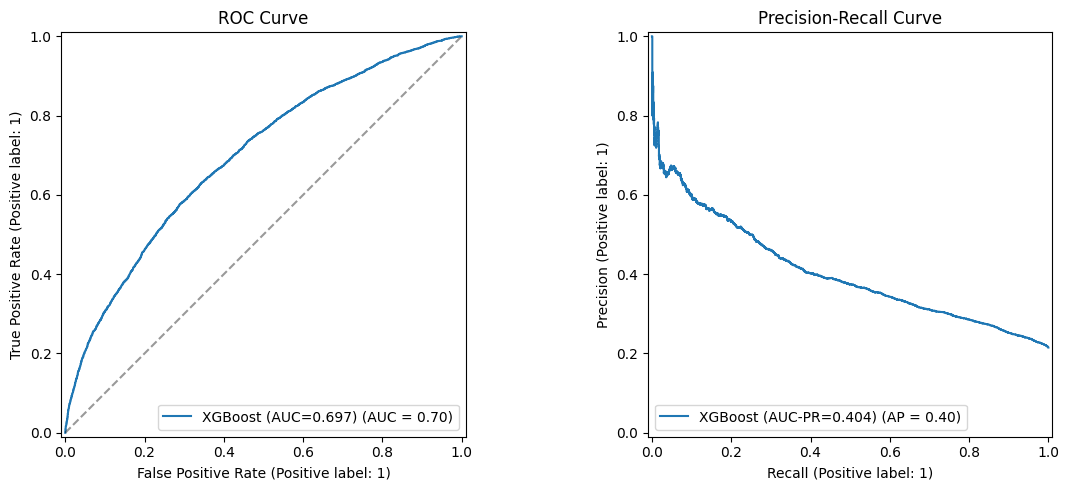

In [15]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(
    y_test, y_pred_proba, ax=axes[0],
    name=f'XGBoost (AUC={auc_roc:.3f})'
)
axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_title('ROC Curve')

PrecisionRecallDisplay.from_predictions(
    y_test, y_pred_proba, ax=axes[1],
    name=f'XGBoost (AUC-PR={auc_pr:.3f})'
)
axes[1].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['No Dementia','Dementia']))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

 No Dementia       0.86      0.66      0.75     15650
    Dementia       0.34      0.62      0.44      4285

    accuracy                           0.65     19935
   macro avg       0.60      0.64      0.59     19935
weighted avg       0.75      0.65      0.68     19935

[[10381  5269]
 [ 1624  2661]]


In [17]:
# lower threshold for screening context -- want higher sensitivity
y_pred_screen = (y_pred_proba >= 0.1).astype(int)
print("threshold = 0.1:")
print(classification_report(y_test, y_pred_screen, target_names=['No Dementia','Dementia']))
print(confusion_matrix(y_test, y_pred_screen))

threshold = 0.1:
              precision    recall  f1-score   support

 No Dementia       0.00      0.00      0.00     15650
    Dementia       0.21      1.00      0.35      4285

    accuracy                           0.21     19935
   macro avg       0.11      0.50      0.18     19935
weighted avg       0.05      0.21      0.08     19935

[[    0 15650]
 [    0  4285]]


## 8. Feature Importance

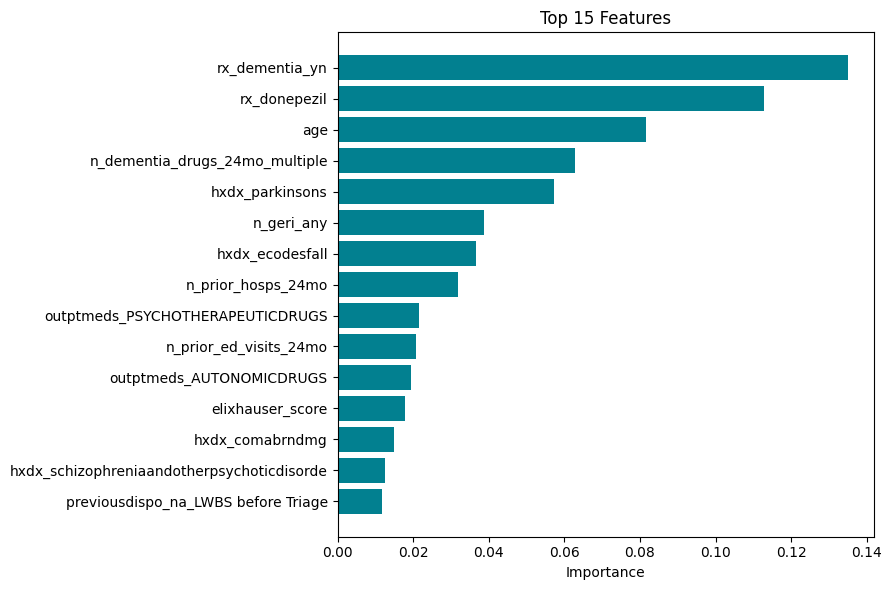

,feature_clean,importance
16,rx_dementia_yn,0.135109
15,rx_donepezil,0.112859
0,age,0.081470
14,n_dementia_drugs_24mo_multiple,0.062891
7,hxdx_parkinsons,0.057322
1,n_geri_any,0.038813
8,hxdx_ecodesfall,0.036560
2,n_prior_hosps_24mo,0.031865
12,outptmeds_PSYCHOTHERAPEUTICDRUGS,0.021529
3,n_prior_ed_visits_24mo,0.020768


In [18]:
import matplotlib.pyplot as plt

feature_names = model.named_steps['preprocessor'].get_feature_names_out()

importance_df = pd.DataFrame({
    'feature':    feature_names,
    'importance': model.named_steps['classifier'].feature_importances_
}).sort_values('importance', ascending=False).head(15)

importance_df['feature_clean'] = (
    importance_df['feature']
      .str.replace('num__', '', regex=False)
      .str.replace('cat__', '', regex=False)
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(importance_df['feature_clean'], importance_df['importance'], color='#028090')
ax.invert_yaxis()
ax.set_xlabel('Importance')
ax.set_title('Top 15 Features')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
importance_df[['feature_clean','importance']].head(15)

In [19]:
try:
    import shap

    X_test_t = model.named_steps['preprocessor'].transform(X_test)
    explainer = shap.TreeExplainer(model.named_steps['classifier'])
    shap_values = explainer.shap_values(X_test_t)

    names_clean = [f.replace('num__','').replace('cat__','') for f in feature_names]

    plt.figure(figsize=(10, 7))
    shap.summary_plot(shap_values, X_test_t, feature_names=names_clean, max_display=15, show=False)
    plt.tight_layout()
    plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()

except ImportError:
    print('pip install shap')

pip install shap


## 9. Threshold Analysis

Sensitivity/specificity tradeoff across thresholds -- mirrors Table 3 in the EDDA paper.

In [20]:
from sklearn.metrics import confusion_matrix

results = []
for thresh in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    y_t = (y_pred_proba >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_t).ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv  = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv  = tn / (tn + fn) if (tn + fn) > 0 else 0
    nnt  = (tp + fp) / tp if tp > 0 else float('inf')
    results.append({'Threshold': thresh, 'Sensitivity': round(sens,2),
                    'Specificity': round(spec,2), 'PPV': round(ppv,2),
                    'NPV': round(npv,2), 'NNT': round(nnt,2),
                    'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn})

pd.DataFrame(results)

,Threshold,Sensitivity,Specificity,PPV,NPV,NNT,TP,FP,FN,TN
0,0.1,1.00,0.00,0.21,0.00,4.65,4285,15650,0,0
1,0.2,0.99,0.04,0.22,0.96,4.54,4259,15060,26,590
2,0.3,0.94,0.19,0.24,0.92,4.15,4027,12676,258,2974
3,0.4,0.81,0.43,0.28,0.89,3.56,3483,8903,802,6747
4,0.5,0.62,0.66,0.34,0.86,2.98,2661,5269,1624,10381
5,0.6,0.39,0.84,0.40,0.83,2.48,1678,2486,2607,13164
6,0.7,0.21,0.95,0.53,0.81,1.90,891,802,3394,14848
7,0.8,0.07,0.99,0.66,0.79,1.52,280,147,4005,15503
8,0.9,0.00,1.00,0.79,0.79,1.27,15,4,4270,15646


## 10. Calibration

Brier score and calibration curve -- are the predicted probabilities reliable?

Brier score: 0.2176


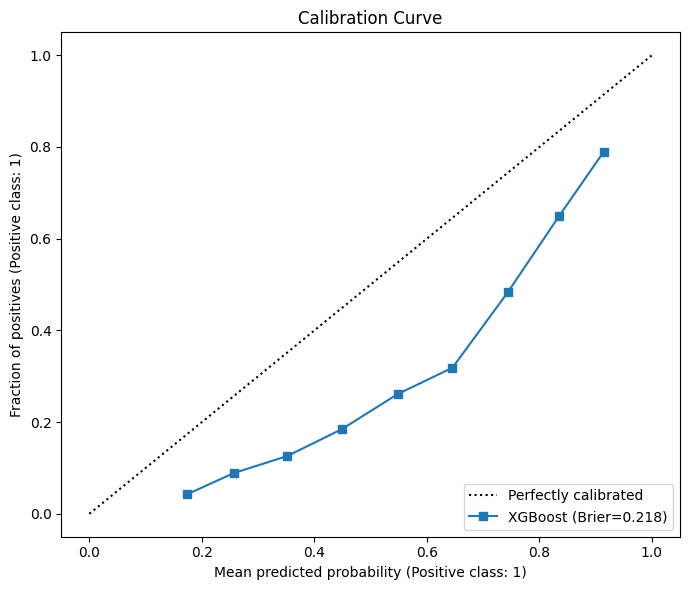

In [21]:
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(y_test, y_pred_proba)
print(f'Brier score: {brier:.4f}')

fig, ax = plt.subplots(figsize=(7, 6))
CalibrationDisplay.from_predictions(
    y_test, y_pred_proba, n_bins=10, ax=ax,
    name=f'XGBoost (Brier={brier:.3f})'
)
ax.set_title('Calibration Curve')
plt.tight_layout()
plt.savefig('calibration_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Subgroup Analysis

AUC by sex, race/ethnicity, insurance -- checking for performance gaps across groups.

In [22]:
from sklearn.metrics import roc_auc_score

subgroup_results = []
for col in ['sex', 'race_ethnicity', 'insurance_status']:
    for group, grp_df in test_df.groupby(col):
        if pd.isna(group) or grp_df['dementia_outcome'].nunique() < 2:
            continue
        X_grp = grp_df.drop(columns=DROP_COLS)
        y_grp = grp_df['dementia_outcome']
        try:
            auc_g = roc_auc_score(y_grp, model.predict_proba(X_grp)[:, 1])
        except:
            auc_g = float('nan')
        subgroup_results.append({'Variable': col, 'Group': group,
                                  'N': len(grp_df), 'Outcome_rate': round(y_grp.mean(),3),
                                  'AUC_ROC': round(auc_g,3)})

subgroup_df = pd.DataFrame(subgroup_results).sort_values(['Variable','AUC_ROC'])
subgroup_df

,Variable,Group,N,Outcome_rate,AUC_ROC
11,insurance_status,Charity Care,30,0.300,0.635
19,insurance_status,Tricare,31,0.258,0.647
13,insurance_status,Medicaid,2070,0.215,0.687
15,insurance_status,Medicare,8390,0.212,0.690
12,insurance_status,Dual (Medicare/Medicaid),2766,0.218,0.695
16,insurance_status,Other,668,0.228,0.696
20,insurance_status,Uninsured,1056,0.209,0.707
17,insurance_status,Private/Commercial,3517,0.221,0.708
21,insurance_status,VA,22,0.182,0.750
18,insurance_status,Self Pay,72,0.236,0.758


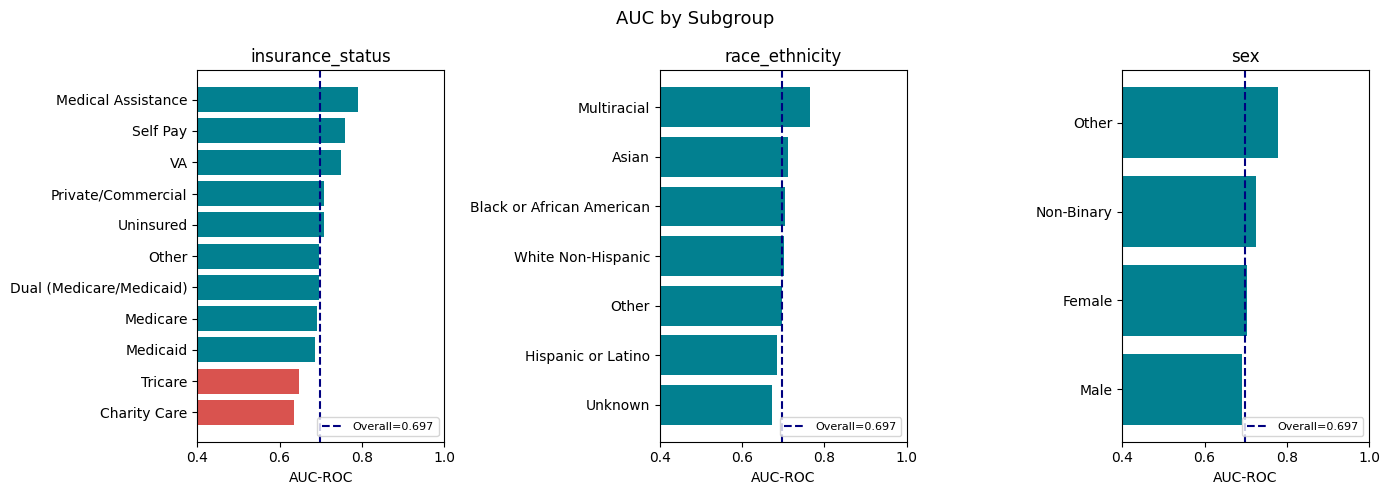

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, (var, gdf) in zip(axes, subgroup_df.groupby('Variable')):
    gdf = gdf.sort_values('AUC_ROC')
    colors = ['#d9534f' if v < 0.65 else '#028090' for v in gdf['AUC_ROC']]
    ax.barh(gdf['Group'].astype(str), gdf['AUC_ROC'], color=colors)
    ax.axvline(x=auc_roc, color='navy', linestyle='--', linewidth=1.5,
               label=f'Overall={auc_roc:.3f}')
    ax.set_xlim(0.4, 1.0)
    ax.set_title(var)
    ax.set_xlabel('AUC-ROC')
    ax.legend(fontsize=8)

plt.suptitle('AUC by Subgroup', fontsize=13)
plt.tight_layout()
plt.savefig('fairness_analysis.png', dpi=150, bbox_inches='tight')
plt.show()